Author: Prachi Arora  
Project: Customer Lifetime Value Prediction  
Dataset: Online Retail Dataset (Kaggle)

# Customer Lifetime Value Prediction
## Phase 1: Data Loading and Initial Exploration

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set display options
pd.set_option("display.max_columns", None)

## Load Dataset

In [3]:
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset Overview

In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Missing Values

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(5268)

## Convert InvoiceDate to Datetime

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [11]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## Create Total Purchase Value

In [12]:
df["TotalPrice"] =  df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Data Cleaning

In [13]:
df = df.dropna(subset=["CustomerID"])

In [14]:
df.shape

(406829, 9)

In [15]:
#Removing product returns (negative values in quantity are returns)
df = df[df["Quantity"] > 0]

In [16]:
df = df[df["UnitPrice"] > 0]

In [17]:
df = df.drop_duplicates()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


## Exploratory Data Analysis

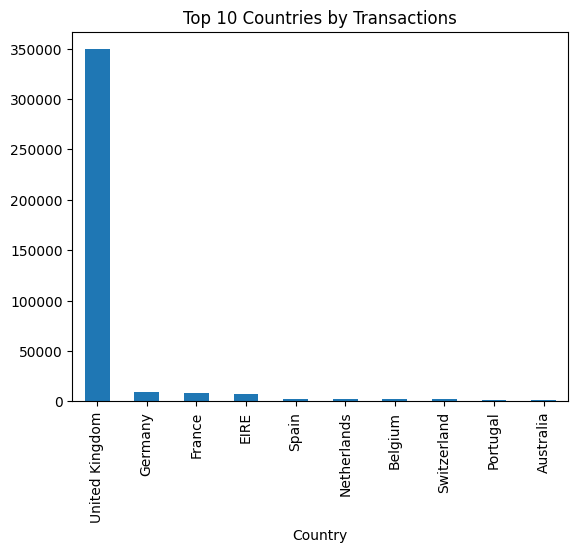

In [19]:
#Top Countries by customers
df["Country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries by Transactions")
plt.show()

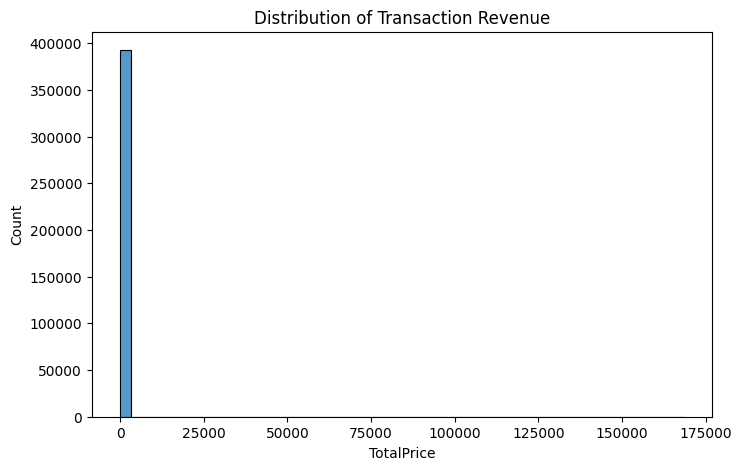

In [20]:
#Revenue distribution
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPrice"], bins = 50)
plt.title("Distribution of Transaction Revenue")
plt.show()

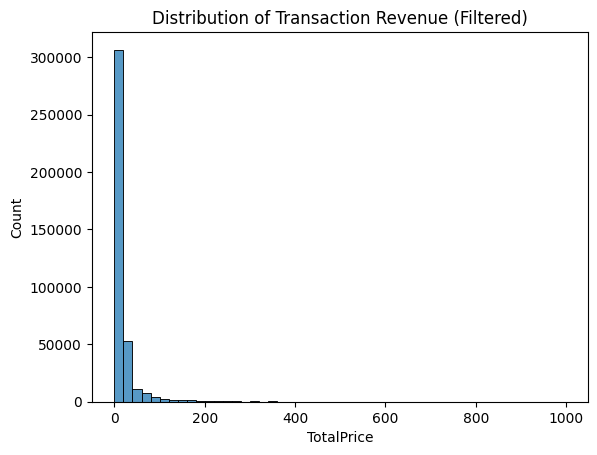

In [21]:
#Filtered Graph
sns.histplot(df[df["TotalPrice"] < 1000]["TotalPrice"], bins=50)
plt.title("Distribution of Transaction Revenue (Filtered)")
plt.show()

In [22]:
#Top Selling Products
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

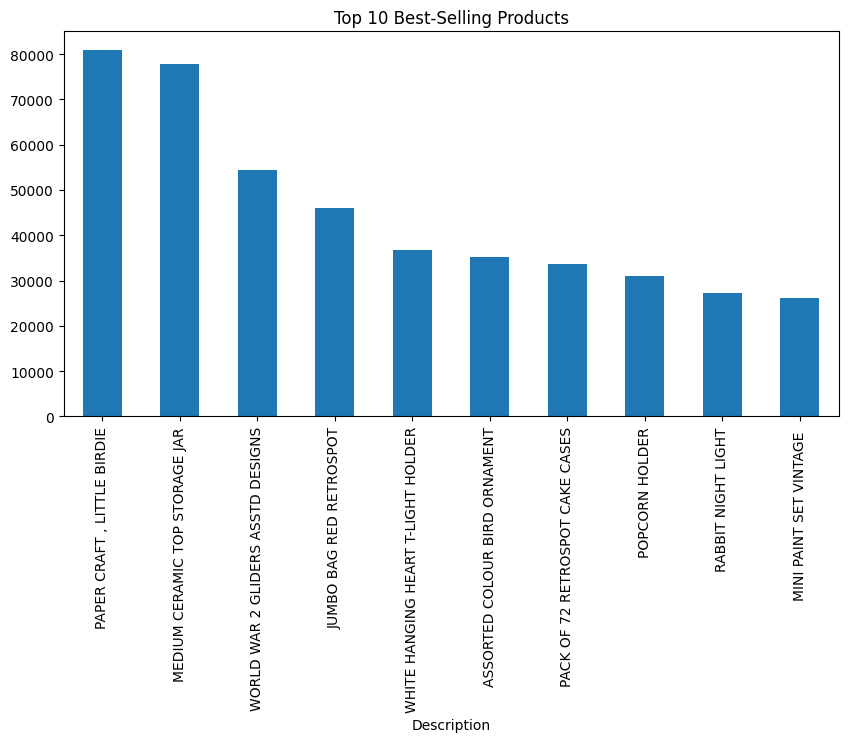

In [23]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Best-Selling Products")
plt.show()

In [24]:
#Monthly sale trends
df["Month"] = df["InvoiceDate"].dt.to_period("M")

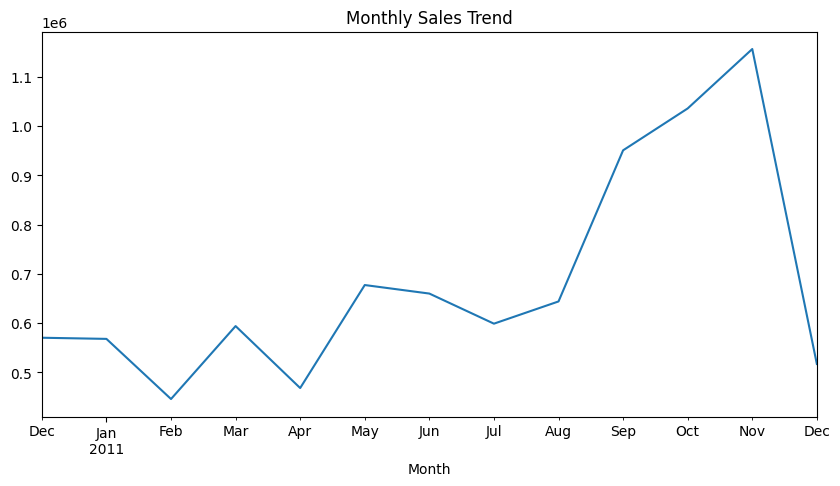

In [25]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.show()

## RFM Feature Engineering

In [26]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days = 1)

In [27]:
#Calculate RFM
rfm = df.groupby("CustomerID").agg( {
    "InvoiceDate" : lambda x: (reference_date - x.max()).days,
    "InvoiceNo" : "nunique",
    "TotalPrice": "sum"
})

In [28]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [29]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## Phase 3: Customer Lifetime Value Prediction

In [30]:
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
X = rfm[["Recency", "Frequency"]]
y = rfm["Monetary"]

## Train-Test Split

In [31]:
rfm = rfm[rfm["Monetary"] < 50000]

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model 1 - Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
lr_predictions = lr_model.predict(X_test)

### Model 2 - Random Forest

In [37]:
from sklearn.ensemble import RandomForestRegressor

In [38]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [39]:
rf_predictions = rf_model.predict(X_test)

## Model Evaluation

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Linear Regression Performance

In [41]:
print("Linear Regression Performance")

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print("MAE: ", mean_absolute_error(y_test, lr_predictions))
print("RMSE: ", lr_rmse)
print("R2 Score: ", r2_score(y_test, lr_predictions))

Linear Regression Performance
MAE:  1450.5339794153952
RMSE:  8202.293605743142
R2 Score:  0.34249225354150525


#### Random Forest Evaluation

In [42]:
print("Random Forest Performance")

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("MAE:", mean_absolute_error(y_test, rf_predictions))
print("RMSE:", rf_rmse)
print("R2 Score:", r2_score(y_test, rf_predictions))

Random Forest Performance
MAE: 1898.095788957496
RMSE: 10691.59493461883
R2 Score: -0.11715965925800198


In [43]:
#Calculating metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

In [44]:
#Calculating metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

In [45]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1450.533979,8202.293606,0.342492
1,Random Forest,1898.095789,10691.594935,-0.117160


In [46]:
model_comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1450.533979,8202.293606,0.342492
1,Random Forest,1898.095789,10691.594935,-0.117160


Linear Regression outperformed Random Forest with a lower MAE (1450.53) and RMSE (8202.29), along with a positive R² score (0.34).

In contrast, Random Forest resulted in higher error values and a negative R² score (-0.11), indicating poor predictive performance on this dataset.

This suggests that customer spending patterns in the dataset have a weak and relatively linear relationship with the available features (Recency and Frequency), and do not benefit from complex non-linear models.

In [47]:
rfm["Monetary"].describe()

count     4318.000000
mean      1565.998248
std       3046.186341
min          3.750000
25%        305.652500
50%        663.905000
75%       1636.237500
max      44534.300000
Name: Monetary, dtype: float64

In [48]:
rfm.shape

(4318, 4)

In [49]:
rfm.corr()

,Recency,Frequency,Monetary,Monetary_log
Recency,1.000000,-0.285282,-0.242076,-0.438042
Frequency,-0.285282,1.000000,0.689188,0.574198
Monetary,-0.242076,0.689188,1.000000,0.681505
Monetary_log,-0.438042,0.574198,0.681505,1.000000


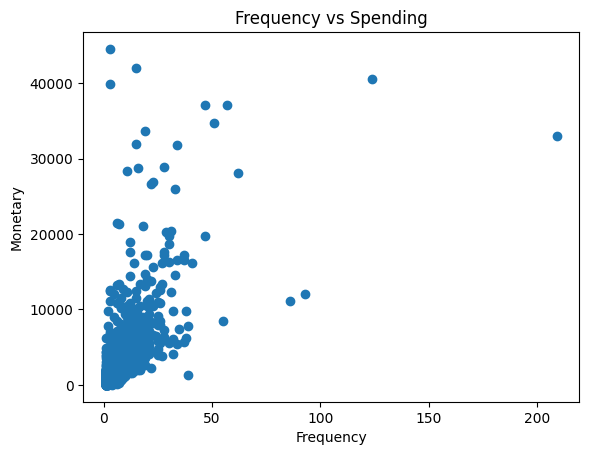

In [50]:
import matplotlib.pyplot as plt

plt.scatter(rfm["Frequency"], rfm["Monetary"])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Spending")
plt.show()

Therefore, Linear Regression was selected as the final model for Customer Lifetime Value (CLV) prediction.

----

## Phase 4: Customer Segmentation and Business Insights

In [51]:
rfm['R_score'] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])

In [52]:
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])

In [53]:
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [54]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str) 
)

rfm.head()

,Recency,Frequency,Monetary,Monetary_log,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,,
12347.0,2,7,4310.00,8.368925,4,4,4,444
12348.0,75,4,1797.24,7.494564,2,3,4,234
12349.0,19,1,1757.55,7.472245,3,1,4,314
12350.0,310,1,334.40,5.815324,1,1,2,112
12352.0,36,8,2506.04,7.826858,3,4,4,344


In [56]:
#Segment Customers

def segment_customer(row):
    if row["RFM_score"] == "444":
        return "Champions"
    elif row["F_score"] == 4:
        return "Loyal Customers"
    elif row["R_score"] == 1:
        return "At Risk"
    else:
        return "Others"
    
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [57]:
rfm["Segment"].value_counts()

Segment
Others             2191
At Risk            1047
Loyal Customers     595
Champions           485
Name: count, dtype: int64

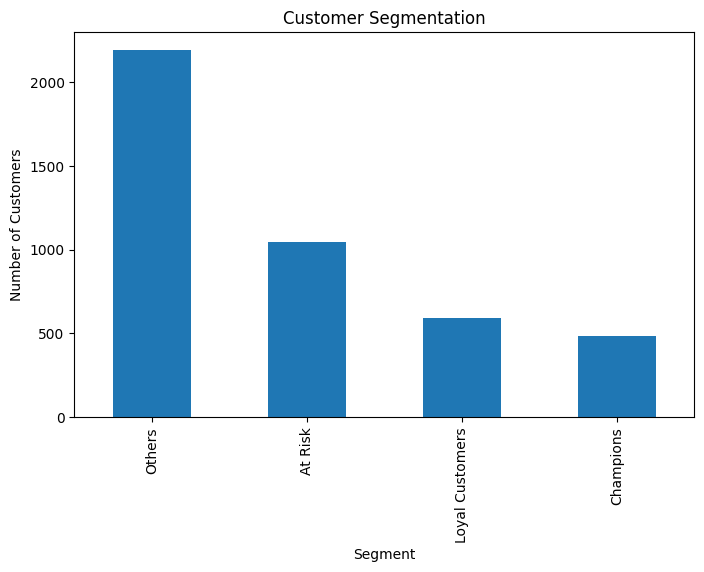

In [58]:
rfm["Segment"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

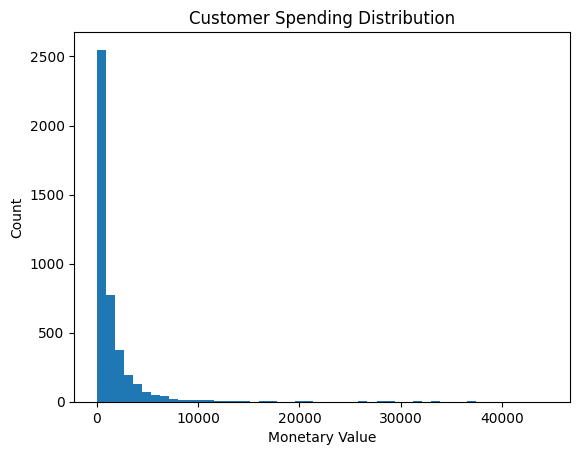

In [60]:
#CLV Distribution Plot
plt.hist(rfm["Monetary"], bins=50)
plt.title("Customer Spending Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")
plt.show()

### Key Business Insights

- A small percentage of customers contribute to a large portion of total revenue.
- High-value customers (Champions) should be targeted with loyalty programs.
- Customers with low recency scores are at risk of churn and require re-engagement strategies.
- Majority of customers fall into lower spending categories, indicating opportunities for upselling.

----

### Final Conclusion

This project successfully implemented a Customer Lifetime Value prediction system using RFM analysis and machine learning models.

Linear Regression outperformed Random Forest, indicating a relatively simple relationship between customer behavior and spending.

Customer segmentation revealed distinct groups such as Champions, Loyal Customers, and At-Risk customers, enabling targeted business strategies.

The project demonstrates how data-driven insights can help businesses improve customer retention, increase revenue, and optimize marketing efforts.